# Automobile Price Analysis

## Exploratory Data Analysis

### Phase 2 Capstone Project

Research Question:
Which car features seem to affect price the most, and can those features also be used to group similar cars together?

## 1. Data Overview

This section introduces the Automobile dataset, including its structure, dimensions, variables, and data types.

In [206]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [207]:
columns = ['symboling', 'normalized_losses', 'make', 'fuel_type', 'aspiration', 'num_of_doors', 'body_style', 'drive_wheels', 'engine_location', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_type', 'num_of_cylinders', 'engine_size', 'fuel_system', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [208]:
df = pd.read_csv('../data/raw/imports-85.data', names=columns, na_values='?')

In [209]:
df.head()

,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [210]:
df.shape

(205, 26)

Our dataset contains 205 automobile records and 26 variables.

In [211]:
df.columns

Index(['symboling', 'normalized_losses', 'make', 'fuel_type', 'aspiration',
       'num_of_doors', 'body_style', 'drive_wheels', 'engine_location',
       'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_type',
       'num_of_cylinders', 'engine_size', 'fuel_system', 'bore', 'stroke',
       'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg',
       'highway_mpg', 'price'],
      dtype='str')

In [212]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized_losses  164 non-null    float64
 2   make               205 non-null    str    
 3   fuel_type          205 non-null    str    
 4   aspiration         205 non-null    str    
 5   num_of_doors       203 non-null    str    
 6   body_style         205 non-null    str    
 7   drive_wheels       205 non-null    str    
 8   engine_location    205 non-null    str    
 9   wheel_base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb_weight        205 non-null    int64  
 14  engine_type        205 non-null    str    
 15  num_of_cylinders   205 non-null    str    
 16  engine_size        205 non-null    in

## 2. Missing Data Analysis

This section examines the dataset for missing values and identifies variables that may require additional preprocessing.

In [213]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

normalized_losses    41
bore                  4
stroke                4
price                 4
num_of_doors          2
horsepower            2
peak_rpm              2
dtype: int64

In [214]:
missing_percent = (df.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({'Missing Values': missing_values, 'Missing Percentage': missing_percent})

missing_summary[missing_summary['Missing Values'] > 0].sort_values(by='Missing Values', ascending=False)

,Missing Values,Missing Percentage
normalized_losses,41,20.00
bore,4,1.95
stroke,4,1.95
price,4,1.95
num_of_doors,2,0.98
horsepower,2,0.98
peak_rpm,2,0.98


In [215]:
df['price'].isnull().sum()

np.int64(4)

In [216]:
df.describe()

,symboling,normalized_losses,wheel_base,length,width,height,curb_weight,engine_size,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
count,205.000000,164.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,201.000000,201.000000,205.000000,203.000000,203.000000,205.000000,205.000000,201.000000
mean,0.834146,122.000000,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329751,3.255423,10.142537,104.256158,5125.369458,25.219512,30.751220,13207.129353
std,1.245307,35.442168,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.273539,0.316717,3.972040,39.714369,479.334560,6.542142,6.886443,7947.066342
min,-2.000000,65.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,115.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,150.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.590000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,256.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


## 3. Price Distribution

This section examines the distribution of automobile prices, including the typical price range, variability, skewness, and potential outliers.

In [217]:
df['price'].describe()

count      201.000000
mean     13207.129353
std       7947.066342
min       5118.000000
25%       7775.000000
50%      10295.000000
75%      16500.000000
max      45400.000000
Name: price, dtype: float64

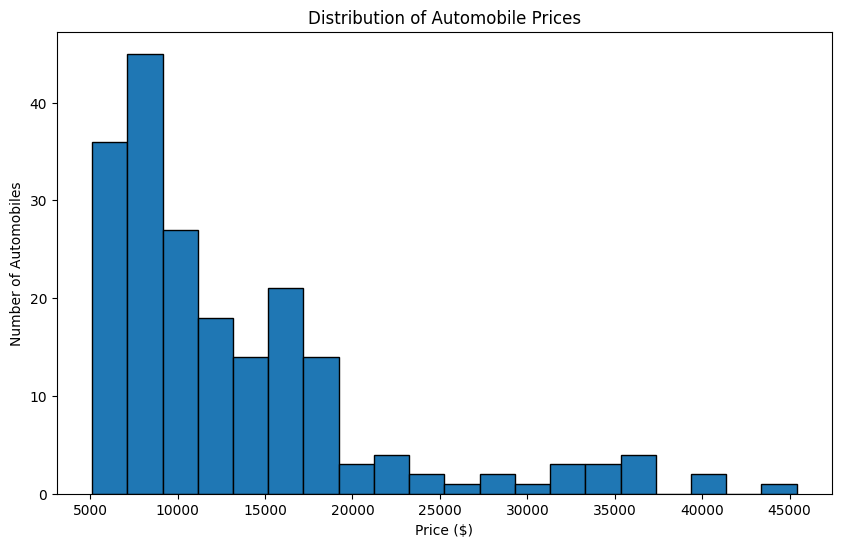

In [218]:
plt.figure(figsize=(10, 6))

plt.hist(df['price'].dropna(), bins=20, edgecolor='black')

plt.title('Distribution of Automobile Prices')
plt.xlabel('Price ($)')
plt.ylabel('Number of Automobiles')

plt.show()

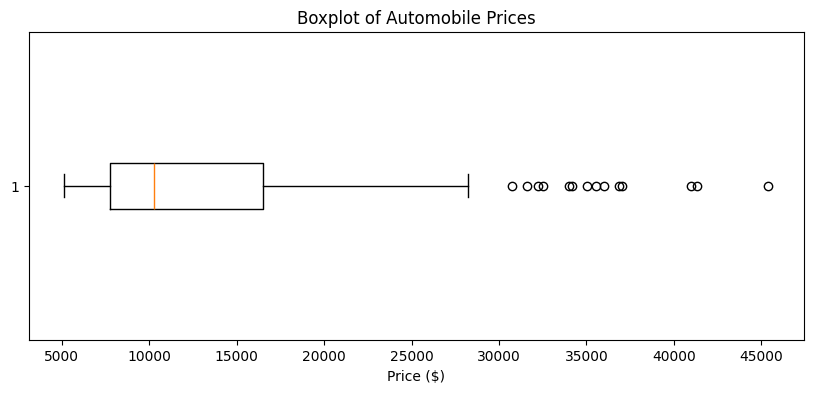

In [219]:
plt.figure(figsize=(10, 4))

plt.boxplot(df['price'].dropna(), vert=False)

plt.title('Boxplot of Automobile Prices')
plt.xlabel('Price ($)')

plt.show()

### Price Distribution Findings

The distribution of automobile prices is strongly right-skewed. Most vehicles in the dataset are concentrated in the lower price range, with the majority priced below approximately $15,000. However, a smaller number of vehicles have substantially higher prices, extending to $45,400.

The median automobile price is $10,295, while the mean price is $13,207. The higher mean is consistent with the right-skewed distribution, where a relatively small number of expensive vehicles increase the average.

The boxplot also identifies several high-priced observations as potential outliers. These observations will not be removed automatically because they may represent legitimate higher-end vehicles rather than data errors.

## 4. Manufacturer and Price Analysis

This section examines how automobile prices vary across manufacturers and identifies potential differences in pricing between vehicle brands.

In [220]:
manufacturer_price = (df.groupby('make')['price'].mean().sort_values(ascending=False))

manufacturer_price

make
jaguar           34600.000000
mercedes-benz    33647.000000
porsche          31400.500000
bmw              26118.750000
volvo            18063.181818
audi             17859.166667
mercury          16503.000000
alfa-romero      15498.333333
peugot           15489.090909
saab             15223.333333
mazda            10652.882353
nissan           10415.666667
volkswagen       10077.500000
toyota            9885.812500
renault           9595.000000
mitsubishi        9239.769231
isuzu             8916.500000
subaru            8541.250000
honda             8184.692308
plymouth          7963.428571
dodge             7875.444444
chevrolet         6007.000000
Name: price, dtype: float64

In [221]:
df['make'].value_counts()

make
toyota           32
nissan           18
mazda            17
honda            13
mitsubishi       13
subaru           12
volkswagen       12
peugot           11
volvo            11
dodge             9
bmw               8
mercedes-benz     8
audi              7
plymouth          7
saab              6
porsche           5
isuzu             4
alfa-romero       3
chevrolet         3
jaguar            3
renault           2
mercury           1
Name: count, dtype: int64

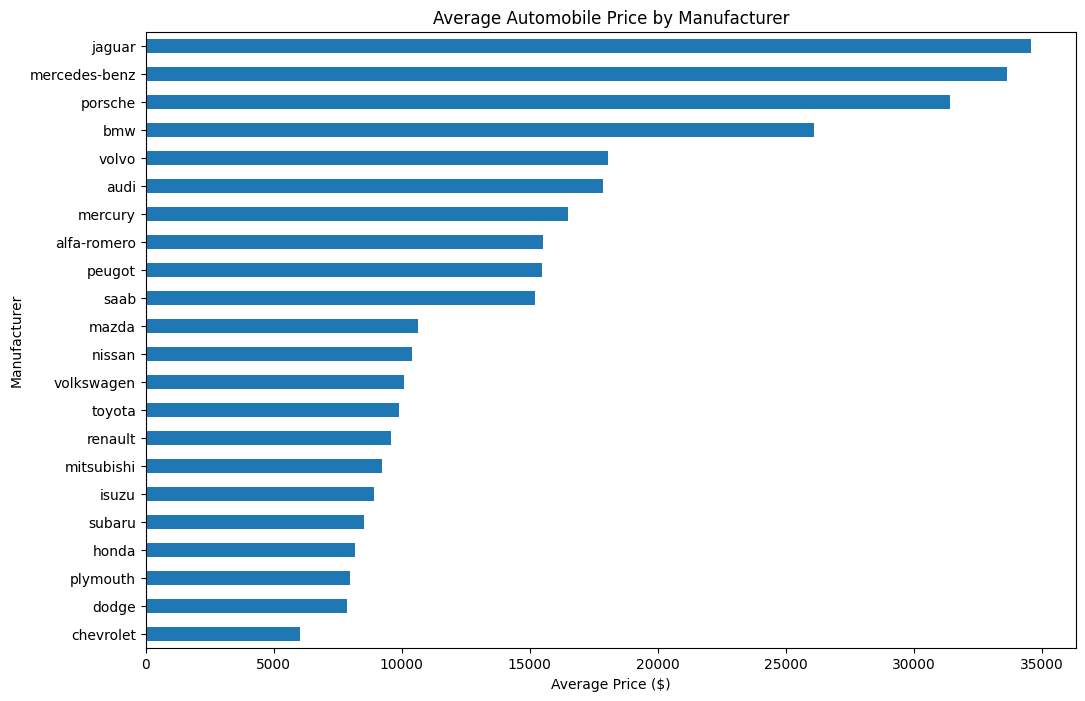

In [222]:
plt.figure(figsize=(12, 8))

manufacturer_price.sort_values().plot(kind='barh')

plt.title('Average Automobile Price by Manufacturer')
plt.xlabel('Average Price ($)')
plt.ylabel('Manufacturer')

plt.show()

### Manufacturer and Price Findings

Average automobile price varies substantially across manufacturers in the dataset. Jaguar has the highest average price at approximately $34,600, followed by Mercedes-Benz at about $33,647 and Porsche at about $31,401. Chevrolet has the lowest average price at approximately $6,007.

However, manufacturer sample sizes vary considerably. Toyota has 32 observations, while Jaguar has only 3, Porsche has 5, and Mercury has just 1. Because some manufacturer averages are based on small sample sizes, these results should be interpreted cautiously.

Overall, the analysis suggests that manufacturer is associated with substantial differences in automobile price, making it a potentially useful categorical feature for later modeling.

## 5. Vehicle Characteristics and Price

This section examines the relationship between automobile price and key vehicle characteristics, including engine size, horsepower, curb weight, and fuel efficiency.

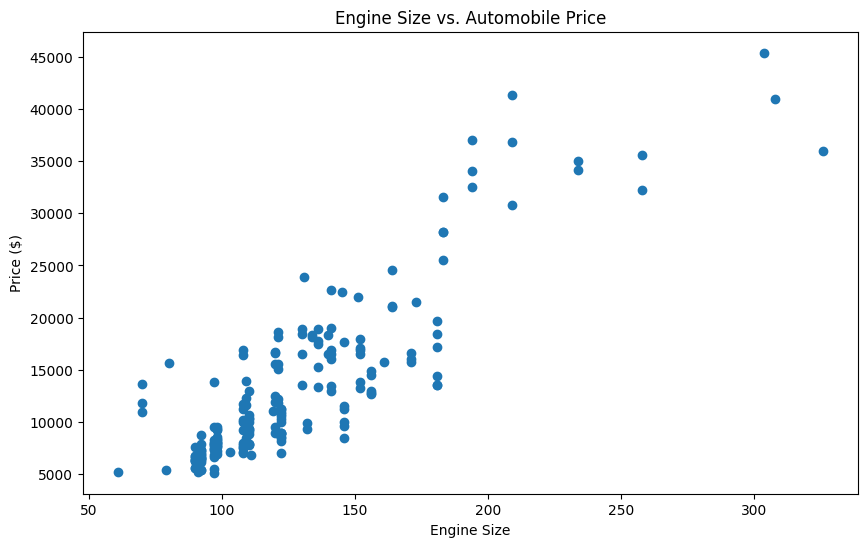

In [223]:
plt.figure(figsize=(10, 6))

plt.scatter(df['engine_size'], df['price'])

plt.title('Engine Size vs. Automobile Price')
plt.xlabel('Engine Size')
plt.ylabel('Price ($)')

plt.show()

In [224]:
df[['engine_size', 'price']].corr()

,engine_size,price
engine_size,1.000000,0.872335
price,0.872335,1.000000


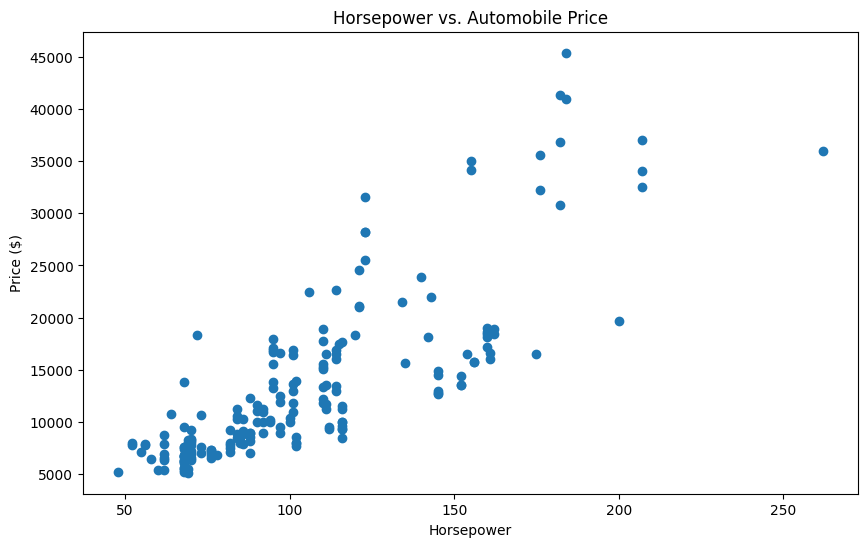

In [225]:
plt.figure(figsize=(10, 6))

plt.scatter(df['horsepower'], df['price'])

plt.title('Horsepower vs. Automobile Price')
plt.xlabel('Horsepower')
plt.ylabel('Price ($)')

plt.show()

In [226]:
df[['horsepower', 'price']].corr()

,horsepower,price
horsepower,1.000000,0.810533
price,0.810533,1.000000


### Horsepower and Price Findings

Horsepower has a strong positive relationship with automobile price. The correlation between horsepower and price is approximately 0.81, indicating that vehicles with greater horsepower generally tend to have higher prices.

Although the scatterplot shows some variation among vehicles with similar horsepower values, the overall upward pattern is clear. This suggests that horsepower may also be an important feature for predicting automobile price.

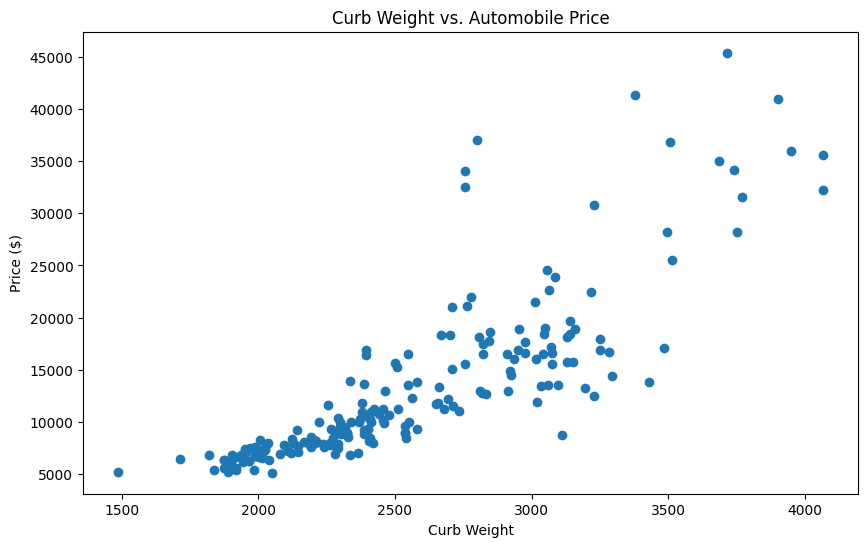

In [227]:
plt.figure(figsize=(10, 6))

plt.scatter(df['curb_weight'], df['price'])

plt.title('Curb Weight vs. Automobile Price')
plt.xlabel('Curb Weight')
plt.ylabel('Price ($)')

plt.show()

In [228]:
df[['curb_weight', 'price']].corr()

,curb_weight,price
curb_weight,1.000000,0.834415
price,0.834415,1.000000


### Curb Weight and Price Findings

Curb weight has a strong positive relationship with automobile price. The correlation between curb weight and price is approximately 0.83, indicating that heavier vehicles generally tend to have higher prices.

The scatterplot shows a clear upward pattern, especially among heavier vehicles. This suggests that curb weight may be an important feature for predicting automobile price.

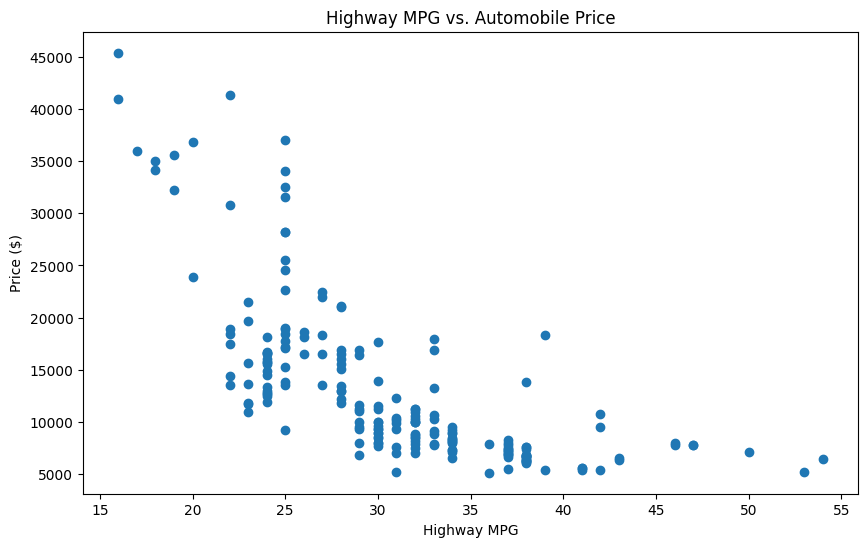

In [229]:
plt.figure(figsize=(10, 6))

plt.scatter(df['highway_mpg'], df['price'])

plt.title('Highway MPG vs. Automobile Price')
plt.xlabel('Highway MPG')
plt.ylabel('Price ($)')

plt.show()

In [230]:
df[['highway_mpg', 'price']].corr()

,highway_mpg,price
highway_mpg,1.000000,-0.704692
price,-0.704692,1.000000


### Highway MPG and Price Findings

Highway fuel efficiency has a strong negative relationship with automobile price. The correlation between highway MPG and price is approximately -0.70, indicating that vehicles with higher highway fuel efficiency generally tend to have lower prices in this dataset.

The scatterplot shows a clear downward pattern, where many of the highest-priced automobiles have relatively low highway MPG. This suggests that fuel efficiency may also provide useful information when predicting automobile price.

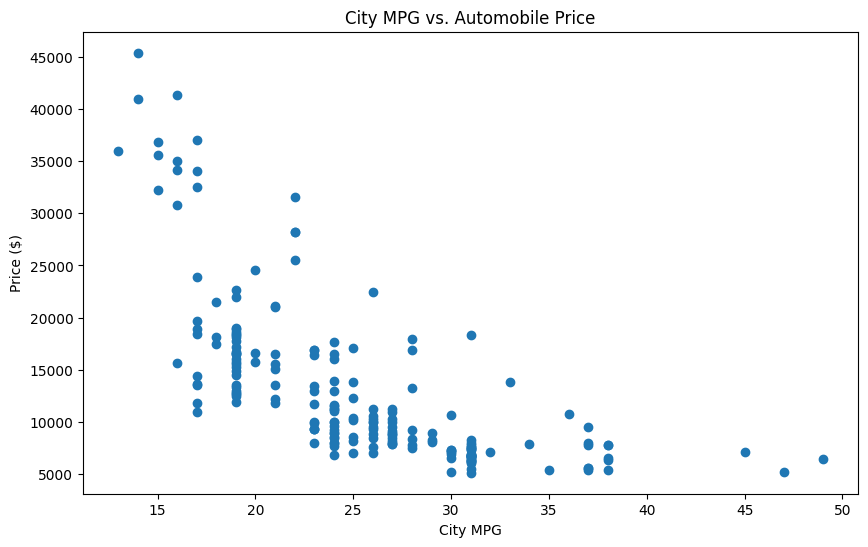

In [231]:
plt.figure(figsize=(10, 6))

plt.scatter(df['city_mpg'], df['price'])

plt.title('City MPG vs. Automobile Price')
plt.xlabel('City MPG')
plt.ylabel('Price ($)')

plt.show()

In [232]:
df[['city_mpg', 'price']].corr()

,city_mpg,price
city_mpg,1.000000,-0.686571
price,-0.686571,1.000000


### City MPG and Price Findings

City fuel efficiency has a moderately strong negative relationship with automobile price. The correlation between city MPG and price is approximately -0.69, indicating that vehicles with higher city fuel efficiency generally tend to have lower prices in this dataset.

The scatterplot shows a clear downward trend, with many of the highest-priced vehicles concentrated at lower city MPG values. This suggests that city fuel efficiency may also be useful when predicting automobile price.

## 6. Correlation Analysis

This section compares the relationships among the numerical variables in the dataset and identifies which features are most strongly associated with automobile price.

In [233]:
numeric_df = df.select_dtypes(include=['number'])

correlation_matrix = numeric_df.corr()

price_correlations = (correlation_matrix['price'].sort_values(ascending=False))

price_correlations

price                1.000000
engine_size          0.872335
curb_weight          0.834415
horsepower           0.810533
width                0.751265
length               0.690628
wheel_base           0.584642
bore                 0.543436
normalized_losses    0.203254
height               0.135486
stroke               0.082310
compression_ratio    0.071107
symboling           -0.082391
peak_rpm            -0.101649
city_mpg            -0.686571
highway_mpg         -0.704692
Name: price, dtype: float64

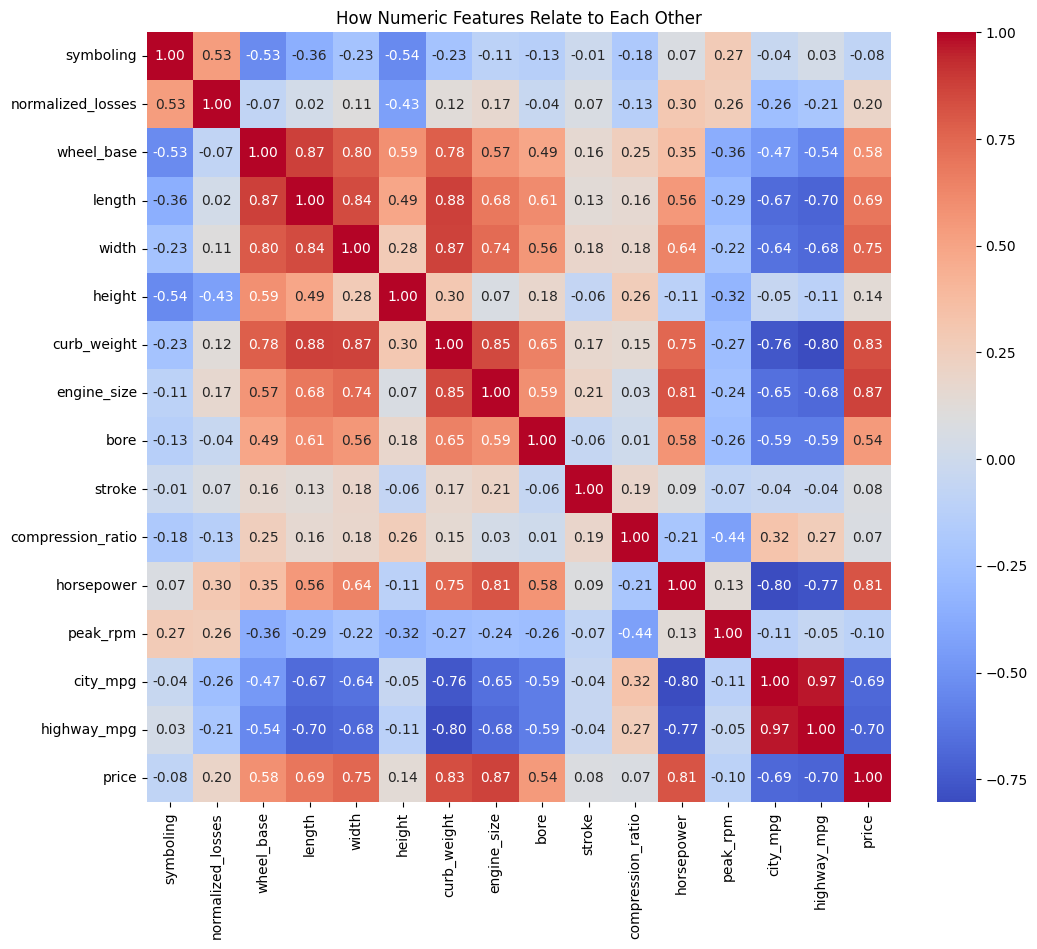

In [234]:
plt.figure(figsize=(12, 10))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('How Numeric Features Relate to Each Other')

plt.show()

### Correlation Findings

The strongest positive relationships with price are engine size, curb weight, horsepower, and vehicle width. Engine size has the strongest correlation with price at approximately 0.87.

City MPG and highway MPG both have strong negative relationships with price, indicating that vehicles with better fuel efficiency tend to have lower prices in this dataset.

The heatmap also shows that several predictor variables are strongly related to one another, such as city MPG and highway MPG, as well as curb weight, vehicle dimensions, and engine size. These relationships will be considered during the modeling stage.

## 7. Categorical Features and Price

This section looks at how automobile prices vary across different vehicle categories.

In [235]:
body_style_price = (df.groupby('body_style')['price'].mean().sort_values(ascending=False))

body_style_price

body_style
hardtop        22208.500000
convertible    21890.500000
sedan          14459.755319
wagon          12371.960000
hatchback       9957.441176
Name: price, dtype: float64

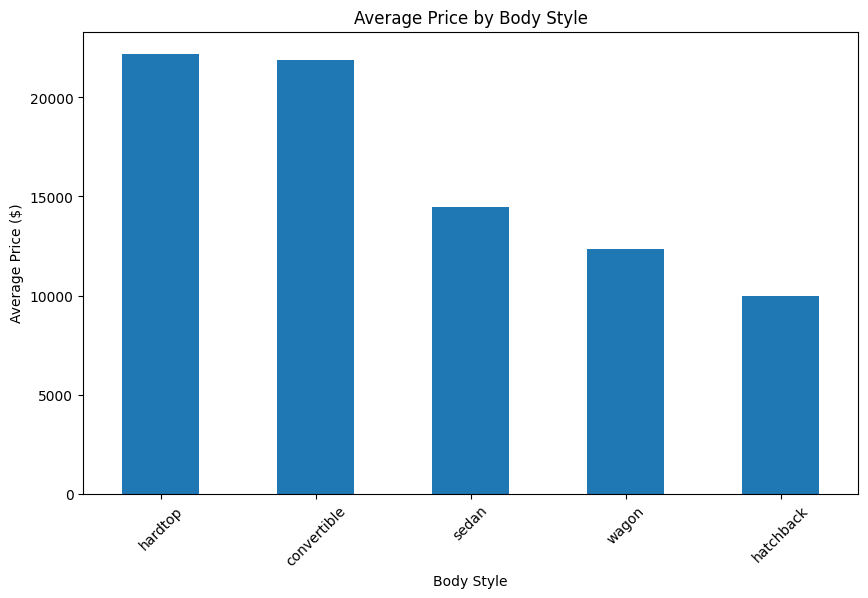

In [236]:
plt.figure(figsize=(10, 6))

body_style_price.plot(kind='bar')

plt.title('Average Price by Body Style')
plt.xlabel('Body Style')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45)

plt.show()

In [237]:
drive_wheels_price = (df.groupby('drive_wheels')['price'].mean().sort_values(ascending=False))

drive_wheels_price

drive_wheels
rwd    19757.613333
4wd    10241.000000
fwd     9244.779661
Name: price, dtype: float64

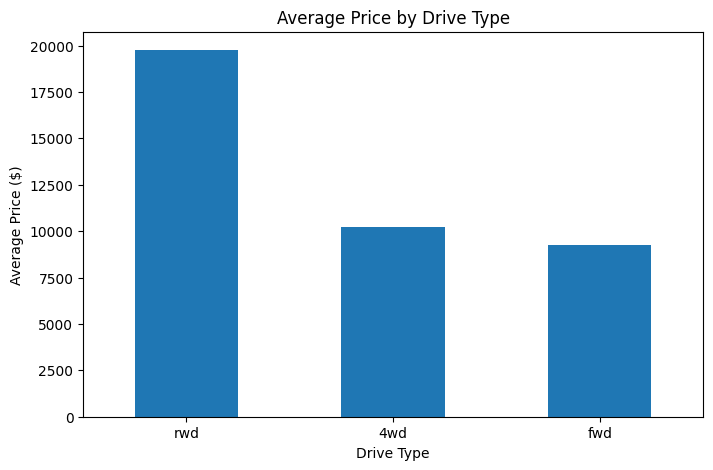

In [238]:
plt.figure(figsize=(8, 5))

drive_wheels_price.plot(kind='bar')

plt.title('Average Price by Drive Type')
plt.xlabel('Drive Type')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=0)

plt.show()

### Categorical Feature Findings

Average automobile price differs noticeably across body styles. Hardtops and convertibles have the highest average prices in the dataset, while hatchbacks have the lowest average price. Sedans and wagons fall between these groups.

Drive type also shows a clear difference in average price. Rear-wheel-drive vehicles have a much higher average price than both four-wheel-drive and front-wheel-drive vehicles.

These results suggest that body style and drive type may be useful categorical features when building a price prediction model.

## 8. Key EDA Findings

The exploratory analysis identified several patterns that may be useful for understanding and predicting automobile prices.

- Automobile prices range from $5,118 to $45,400, with an average price of approximately $13,207 and a median price of $10,295.
- The price distribution is right-skewed, with most vehicles concentrated in the lower price range and a smaller number of substantially more expensive vehicles.
- Engine size has the strongest positive relationship with price among the numerical features examined, with a correlation of approximately 0.87.
- Curb weight and horsepower also have strong positive relationships with price, with correlations of approximately 0.83 and 0.81.
- Vehicle width and length show additional positive relationships with price.
- Highway MPG and city MPG have negative relationships with price, with correlations of approximately -0.70 and -0.69. In this dataset, more fuel-efficient vehicles generally tend to have lower prices.
- Average price varies considerably by manufacturer, although some manufacturers have relatively small sample sizes and should therefore be interpreted cautiously.
- Hardtops and convertibles have the highest average prices among body styles, while hatchbacks have the lowest.
- Rear-wheel-drive vehicles have a noticeably higher average price than four-wheel-drive and front-wheel-drive vehicles.
- Several features are also highly correlated with one another. For example, city MPG and highway MPG have a correlation of approximately 0.97. This may be important when selecting features for later modeling.

### Next Steps

Based on these findings, the next stage will focus on preprocessing the data. This will include handling missing values, preparing categorical variables for modeling, and determining which numerical features may require scaling or additional transformation.

# Data Preprocessing

This section prepares the automobile dataset for clustering and supervised modeling by handling missing values, preparing categorical variables, and scaling numerical features where appropriate.

## 1. Handling Missing Values

In [239]:
df.isnull().sum()[df.isnull().sum() > 0]

normalized_losses    41
num_of_doors          2
bore                  4
stroke                4
horsepower            2
peak_rpm              2
price                 4
dtype: int64

In [240]:
df = df.dropna(subset=['price'])

In [241]:
df.shape

(201, 26)

In [242]:
df['price'].isnull().sum()

np.int64(0)

### Missing Numerical Values

Missing numerical values were filled using the median of each variable. The median was selected because it is less sensitive to extreme values and helps preserve the overall distribution of the data.

In [243]:
numeric_missing = ['normalized_losses', 'bore', 'stroke', 'horsepower', 'peak_rpm']

for column in numeric_missing:df[column] = df[column].fillna(df[column].median())

In [244]:
df[numeric_missing].isnull().sum()

normalized_losses    0
bore                 0
stroke               0
horsepower           0
peak_rpm             0
dtype: int64

In [245]:
df['num_of_doors'].value_counts()

num_of_doors
four    113
two      86
Name: count, dtype: int64

In [246]:
df['num_of_doors'] = df['num_of_doors'].fillna(df['num_of_doors'].mode()[0])

In [247]:
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

## 2. Preparing Categorical Variables

Machine learning models require numerical inputs, so the categorical variables in the dataset will be converted into numerical form using one-hot encoding.

In [248]:
categorical_columns = df.select_dtypes(include=['object', 'string']).columns

categorical_columns

Index(['make', 'fuel_type', 'aspiration', 'num_of_doors', 'body_style',
       'drive_wheels', 'engine_location', 'engine_type', 'num_of_cylinders',
       'fuel_system'],
      dtype='str')

In [249]:
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True, dtype=int)

In [250]:
df_encoded.shape

(201, 65)

In [251]:
df_encoded.head()

,symboling,normalized_losses,wheel_base,length,width,height,curb_weight,engine_size,bore,stroke,...,num_of_cylinders_three,num_of_cylinders_twelve,num_of_cylinders_two,fuel_system_2bbl,fuel_system_4bbl,fuel_system_idi,fuel_system_mfi,fuel_system_mpfi,fuel_system_spdi,fuel_system_spfi
0,3,115.0,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,0,0,0,0,0,0,0,1,0,0
1,3,115.0,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,0,0,0,0,0,0,0,1,0,0
2,1,115.0,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,...,0,0,0,0,0,0,0,1,0,0
3,2,164.0,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,...,0,0,0,0,0,0,0,1,0,0
4,2,164.0,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,...,0,0,0,0,0,0,0,1,0,0


In [252]:
df_encoded.dtypes.value_counts()

int64      54
float64    11
Name: count, dtype: int64

### Categorical Encoding Results

The categorical variables were converted into numerical dummy variables using one-hot encoding. The encoded dataset contains 201 observations and 65 columns. The original cleaned dataframe was kept separately so that categorical labels remain readable for later analysis and dashboarding.

In [253]:
df_encoded.isnull().sum().sum()

np.int64(0)

In [254]:
df_encoded.select_dtypes(exclude=['number']).columns

Index([], dtype='str')

## 3. Preparing Numerical Features

The target variable is automobile price. The remaining variables will be used as potential predictor features. Feature scaling will be applied later where appropriate, particularly for K-Means clustering and models that are sensitive to differences in feature scale.

In [255]:
X = df_encoded.drop(columns=['price'])
y = df_encoded['price']

In [256]:
X.shape, y.shape

((201, 64), (201,))

## 4. Saving the Processed Data

In [257]:
df.to_csv('../data/processed/automobile_cleaned.csv', index=False)

In [258]:
df_encoded.to_csv('../data/processed/automobile_encoded.csv', index=False)

## 5. Preprocessing Summary

The automobile dataset was prepared for further analysis and modeling through several preprocessing steps:

- Four observations with missing price values were removed because price is the target variable for supervised modeling.
- Missing numerical values in normalized losses, bore, stroke, horsepower, and peak RPM were filled using the median of each variable.
- Missing values in number of doors were filled using the most frequently occurring category.
- Categorical variables were converted into numerical dummy variables using one-hot encoding.
- A readable cleaned dataset was preserved for analysis and dashboarding, while a separate encoded dataset was created for machine learning.
- Feature scaling will be performed during the modeling process where required to avoid data leakage and to match the needs of each algorithm.

In [259]:
df.shape

(201, 26)

In [260]:
df.isnull().sum().sum()

np.int64(0)

In [261]:
df_encoded.shape

(201, 65)

In [262]:
df_encoded.isnull().sum().sum()

np.int64(0)

# Unsupervised Learning

The goal of this section is to identify groups of automobiles with similar characteristics using K-Means clustering. These groups can help reveal patterns within the dataset and may also provide useful information for the later price prediction models.

## 1. Selecting Features for Clustering

In [263]:
cluster_features = ['engine_size', 'horsepower', 'curb_weight', 'city_mpg', 'highway_mpg', 'length', 'width']

In [264]:
cluster_data = df[cluster_features]

cluster_data.head()

,engine_size,horsepower,curb_weight,city_mpg,highway_mpg,length,width
0,130,111.0,2548,21,27,168.8,64.1
1,130,111.0,2548,21,27,168.8,64.1
2,152,154.0,2823,19,26,171.2,65.5
3,109,102.0,2337,24,30,176.6,66.2
4,136,115.0,2824,18,22,176.6,66.4


In [265]:
cluster_data.shape

(201, 7)

## 2. Scaling the Clustering Features

Because K-Means clustering is based on distance, the selected numerical features need to be placed on a similar scale. Standardization will be used so that features with larger numerical ranges do not dominate the clustering process.

In [266]:
from sklearn.preprocessing import StandardScaler

In [267]:
scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(cluster_data)

In [268]:
cluster_scaled.shape

(201, 7)

In [269]:
cluster_scaled.mean(axis=0)

array([-3.75597839e-17,  1.45820338e-16,  3.00478271e-16,  5.30255773e-17,
       -2.14311708e-16, -1.06051155e-16,  8.70503227e-16])

In [270]:
cluster_scaled.std(axis=0)

array([1., 1., 1., 1., 1., 1., 1.])

## 3. Choosing the Number of Clusters

The elbow method is used to compare different values of K and identify a reasonable number of clusters. The goal is to find the point where adding more clusters produces smaller improvements in the within-cluster variation.

In [271]:
from sklearn.cluster import KMeans

In [272]:
inertia = []

k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k, 
        random_state=42, 
        n_init=10)

    kmeans.fit(cluster_scaled)

    inertia.append(kmeans.inertia_)

print(inertia)

[1407.0, 662.3136972765963, 481.8348388861202, 368.462539991369, 308.2355649798975, 267.24367224349555, 241.90850253128528, 222.4217933238345, 208.6403086878295, 189.23112281894765]


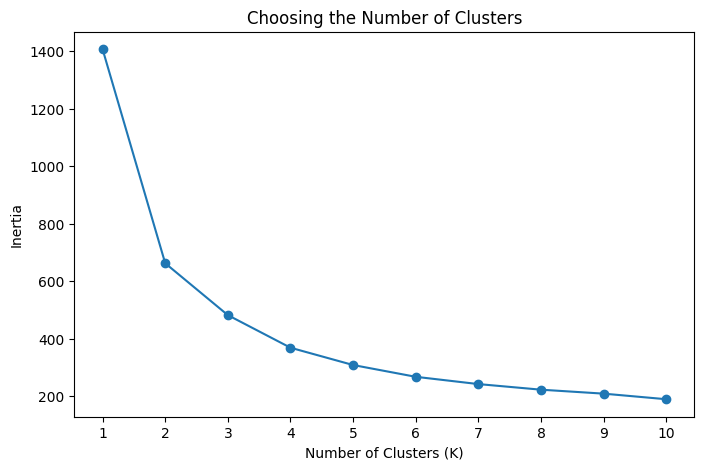

In [273]:
plt.figure(figsize=(8,5))

plt.plot(k_values, inertia, marker='o')

plt.title('Choosing the Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

plt.xticks(k_values)

plt.show()

### Elbow Method Finding

The elbow plot shows a noticeable bend around K = 3. After three clusters, the decrease in inertia becomes more gradual. Based on this pattern, three clusters were selected for the K-Means model.

In [274]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(cluster_scaled)

In [275]:
df['cluster'] = cluster_labels

In [276]:
df['cluster'].value_counts().sort_index()

cluster
0    64
1    79
2    58
Name: count, dtype: int64

In [277]:
cluster_summary = (df.groupby('cluster')[cluster_features + ['price']].mean().round(2))

cluster_summary

,engine_size,horsepower,curb_weight,city_mpg,highway_mpg,length,width,price
cluster,,,,,,,,
0,169.53,143.44,3175.61,19.34,24.11,186.46,68.19,21520.41
1,115.78,97.28,2446.20,24.30,30.15,173.45,65.38,11031.75
2,94.91,67.26,2020.69,32.81,38.67,161.70,64.03,6996.88


## 4. Interpreting the Clusters

The K-Means model produced three distinct groups of automobiles.

- **Cluster 0** represents larger, heavier, and more powerful vehicles. These cars have the highest average engine size, horsepower, curb weight, and price, while also having the lowest fuel efficiency.
- **Cluster 1** represents mid-range vehicles with moderate performance, size, fuel efficiency, and price.
- **Cluster 2** represents smaller, lighter, and more fuel-efficient vehicles. These cars have the lowest average engine size, horsepower, curb weight, and price, while having the highest city and highway MPG.

The clustering results reveal meaningful differences in vehicle characteristics and show that automobiles in the dataset naturally separate into higher-performance, mid-range, and economy-oriented groups.

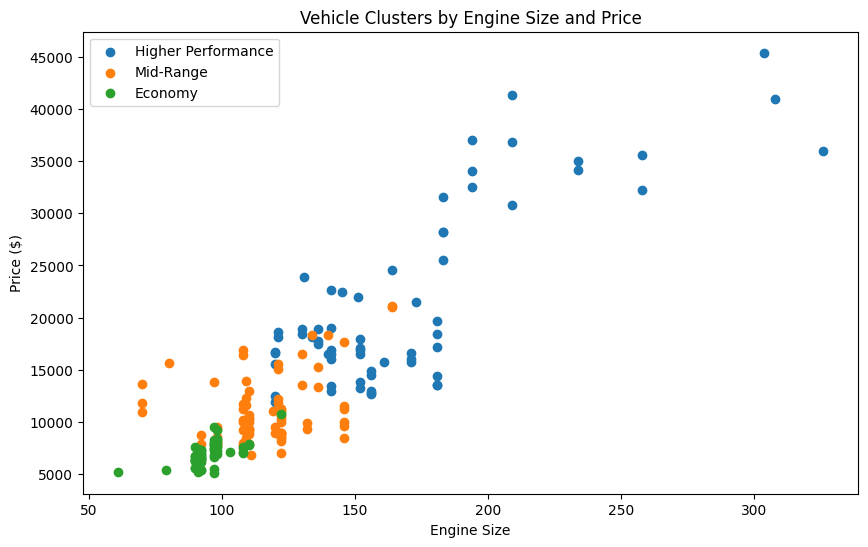

In [278]:
plt.figure(figsize=(10, 6))

labels = {
    0: "Higher Performance",
    1: "Mid-Range",
    2: "Economy"
}

for cluster in sorted(df['cluster'].unique()):
    cluster_df = df[df['cluster'] == cluster]

    plt.scatter(
        cluster_df['engine_size'], 
        cluster_df['price'], 
        label=labels[cluster]
    )

plt.title('Vehicle Clusters by Engine Size and Price')
plt.xlabel('Engine Size')
plt.ylabel('Price ($)')
plt.legend()

plt.show()

### Cluster Visualization

The visualization shows noticeable differences among the three vehicle clusters. The higher-performance cluster generally contains vehicles with larger engines and higher prices, while the economy-oriented cluster is concentrated among smaller-engine, lower-priced vehicles. The mid-range cluster falls between these groups.

Price was not included as a feature when creating the clusters, so the differences in price provide additional evidence that the clusters represent meaningful automobile segments.

# Supervised Learning

The goal of this section is to predict automobile price using vehicle characteristics and compare multiple regression models to determine which approach performs best.

## 1. Preparing the Data

In [279]:
df_model = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

In [280]:
df_model.shape

(201, 66)

In [281]:
X = df_model.drop(columns=['price'])
y = df_model['price']

In [282]:
X.shape, y.shape

((201, 65), (201,))

## 2. Train-Test Split

The dataset is divided into training and testing sets. The training data will be used to build the models, while the testing data will be used to evaluate how well the models perform on unseen observations.

In [283]:
from sklearn.model_selection import train_test_split

In [284]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [285]:
X_train.shape, X_test.shape

((160, 65), (41, 65))

## 3. Linear Regression

Linear Regression will be used as a baseline model to measure how well the automobile features can predict price.

In [286]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [287]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](65,)","[-165.05, -4.65, 188.75,...,1952. ,1253.97,2108.85]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](65,)","['symboling','normalized_losses','wheel_base',...,'fuel_system_mpfi', 'fuel_system_spdi','fuel_system_spfi']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-6254
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,65
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(60)


In [288]:
linear_predictions = linear_model.predict(X_test)

In [289]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print('Linear Regression')
print('MAE:', round(linear_mae, 2))
print('RMSE:', round(linear_rmse, 2))
print('R^2:', round(linear_r2, 3))

Linear Regression
MAE: 1961.06
RMSE: 3170.2
R^2: 0.918


### Linear Regression Initial Result

The initial Linear Regression model achieved an R² score of approximately 0.92, with a mean absolute error of about $1,961. This indicates strong predictive performance on the test data.

For the main model comparison, the cluster feature will first be excluded so that the baseline supervised models can be evaluated independently. The cluster feature will then be tested separately to determine whether the unsupervised learning results improve prediction performance.

In [290]:
X = df_model.drop(columns=['price', 'cluster'])
y = df_model['price']

In [291]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [292]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

In [293]:
linear_mae = mean_absolute_error(y_test, linear_predictions)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_predictions)
)

linear_r2 = r2_score(y_test, linear_predictions)

print('Linear Regression')
print('MAE:', round(linear_mae, 2))
print('RMSE:', round(linear_rmse, 2))
print('R^2:', round(linear_r2, 3))

Linear Regression
MAE: 2031.49
RMSE: 3299.06
R^2: 0.911


## 4. Random Forest Regression

Random Forest Regression will be used as a nonlinear model that can capture more complex relationships between automobile characteristics and price.

In [294]:
from sklearn.ensemble import RandomForestRegressor

In [295]:
random_forest_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [296]:
rf_predictions = random_forest_model.predict(X_test)

In [297]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print('Random Forest Regression')
print('MAE:', round(rf_mae, 2))
print('RMSE:', round(rf_rmse, 2))
print('R^2:', round(rf_r2, 3))

Random Forest Regression
MAE: 1880.18
RMSE: 2908.92
R^2: 0.931


### Random Forest Result

Random Forest Regression performed better than the baseline Linear Regression model. It achieved an R² score of approximately 0.93, with a mean absolute error of about $1,880.

This suggests that the relationship between automobile characteristics and price may include nonlinear patterns that Random Forest is able to capture more effectively than Linear Regression.

## 5. Gradient Boosting Regression

Gradient Boosting Regression will be used as another nonlinear approach. The model builds a sequence of smaller decision trees, with each tree attempting to improve the errors made by the previous trees.

In [298]:
from sklearn.ensemble import GradientBoostingRegressor

In [299]:
gradient_model = GradientBoostingRegressor(
    random_state=42
)

gradient_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [300]:
gradient_predictions = gradient_model.predict(X_test)

In [301]:
gradient_mae = mean_absolute_error(
    y_test,
    gradient_predictions
)

gradient_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gradient_predictions
    )
)

gradient_r2 = r2_score(
    y_test,
    gradient_predictions
)

print('Gradient Boosting Regression')
print('MAE:', round(gradient_mae, 2))
print('RMSE:', round(gradient_rmse, 2))
print('R^2:', round(gradient_r2, 3))

Gradient Boosting Regression
MAE: 1632.51
RMSE: 2518.1
R^2: 0.948


### Gradient Boosting Result

Gradient Boosting Regression produced the strongest performance of the three baseline models. It achieved an R² score of approximately 0.95, with a mean absolute error of about $1,633 and an RMSE of approximately $2,518.

Compared with Linear Regression and Random Forest, Gradient Boosting produced lower prediction errors and explained a greater proportion of the variation in automobile prices.

## 6. Model Comparison

The three regression models are compared using mean absolute error (MAE), root mean squared error (RMSE), and R². Lower MAE and RMSE values indicate smaller prediction errors, while a higher R² indicates that the model explains more variation in automobile price.

In [302]:
model_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'MAE': [
        linear_mae,
        rf_mae,
        gradient_mae
    ],
    'RMSE': [
        linear_rmse,
        rf_rmse,
        gradient_rmse
    ],
    'R2': [
        linear_r2,
        rf_r2,
        gradient_r2
    ]
})

model_results.round(3)

,Model,MAE,RMSE,R2
0,Linear Regression,2031.491,3299.060,0.911
1,Random Forest,1880.178,2908.915,0.931
2,Gradient Boosting,1632.505,2518.102,0.948


## 7. Testing the Cluster Feature

The K-Means cluster labels will now be added as an additional feature to test whether the unsupervised learning results improve the performance of the best supervised model.

In [303]:
X_cluster = df_model.drop(columns=['price'])
y_cluster = df_model['price']

In [304]:
X_train_cluster, X_test_cluster, y_train_cluster, y_test_cluster = train_test_split(
    X_cluster,
    y_cluster,
    test_size=0.2,
    random_state=42
)

In [305]:
gradient_cluster_model = GradientBoostingRegressor(
    random_state=42
)

gradient_cluster_model.fit(
    X_train_cluster,
    y_train_cluster
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [306]:
gradient_cluster_predictions = gradient_cluster_model.predict(
    X_test_cluster
)

In [307]:
gradient_cluster_mae = mean_absolute_error(
    y_test_cluster,
    gradient_cluster_predictions
)

gradient_cluster_rmse = np.sqrt(
    mean_squared_error(
        y_test_cluster,
        gradient_cluster_predictions
    )
)

gradient_cluster_r2 = r2_score(
    y_test_cluster,
    gradient_cluster_predictions
)

print('Gradient Boosting with Cluster')
print('MAE:', round(gradient_cluster_mae, 2))
print('RMSE:', round(gradient_cluster_rmse, 2))
print('R^2:', round(gradient_cluster_r2, 3) )

Gradient Boosting with Cluster
MAE: 1633.02
RMSE: 2473.3
R^2: 0.95


In [308]:
cluster_comparison = pd.DataFrame({
    'Model': [
        'Gradient Boosting',
        'Gradient Boosting + Cluster'
    ],
    'MAE': [
        gradient_mae,
        gradient_cluster_mae
    ],
    'RMSE': [
        gradient_rmse,
        gradient_cluster_rmse
    ],
    'R^2': [
        gradient_r2,
        gradient_cluster_r2
    ]
})

cluster_comparison.round(3)

,Model,MAE,RMSE,R^2
0,Gradient Boosting,1632.505,2518.102,0.948
1,Gradient Boosting + Cluster,1633.020,2473.301,0.950


### Cluster Feature Findings

Adding the K-Means cluster label to the Gradient Boosting model produced only a small change in performance. R² increased from approximately 0.948 to 0.950, while RMSE decreased from about $2,518 to $2,473. However, MAE increased slightly from approximately $1,633 to $1,633.

Overall, the cluster feature did not produce a meaningful improvement in predictive performance. The clustering analysis was more useful as a way to identify and interpret different automobile segments than as an additional feature for price prediction.

However, MAE increased very slightly from approximately $1,632.51 to $1,633.02.

## 8. Supervised Learning Summary

Three regression approaches were evaluated for predicting automobile price: Linear Regression, Random Forest Regression, and Gradient Boosting Regression.

Linear Regression provided a strong baseline with an R² of approximately 0.91. Random Forest improved performance to an R² of approximately 0.93, while Gradient Boosting produced the strongest overall baseline results with an R² of approximately 0.95, an MAE of about $1,633, and an RMSE of about $2,518.

The results suggest that nonlinear models are better able to capture the relationships between automobile characteristics and price in this dataset. Gradient Boosting was selected as the strongest supervised model based on its lower prediction errors and higher R².

The K-Means cluster feature was also tested with Gradient Boosting. Although R² and RMSE improved slightly, MAE remained essentially unchanged. Therefore, clustering provided more value as a segmentation and interpretation tool than as a major source of additional predictive power.